In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow  import keras
from keras.models import  Sequential
from keras.layers import Dense,Conv2D,Flatten,BatchNormalization,MaxPooling2D,Dropout
from keras.applications.vgg16 import VGG16 
from tensorflow.keras.callbacks import EarlyStopping

In [26]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(rescale=1./255)
val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    "../data/train",
    target_size=(128,128),
    batch_size=16,
    class_mode='binary'
)

val_data = val_gen.flow_from_directory(
    "../data/val",
    target_size=(128,128),
    batch_size=16,
    class_mode='binary'
)

test_data = test_gen.flow_from_directory(
    "../data/test",
    target_size=(128,128),
    batch_size=16,
    class_mode='binary'
)

Found 17471 images belonging to 2 classes.
Found 4991 images belonging to 2 classes.
Found 2497 images belonging to 2 classes.


In [27]:
conv_base = VGG16(weights="imagenet", include_top=False, input_shape=(128, 128, 3))

In [28]:
conv_base.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 128, 128, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 128, 128, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 128, 128, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 64, 64, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 64, 64, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 64, 64, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 32, 32, 128)       0     

In [ ]:
model = Sequential()

model.add(conv_base)
model.add(Flatten())
model.add(Dense(256, activation="relu"))
model.add(Dense(1, activation="sigmoid"))

In [31]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 4, 4, 512)         14714688  
                                                                 
 flatten_1 (Flatten)         (None, 8192)              0         
                                                                 
 dense_2 (Dense)             (None, 256)               2097408   
                                                                 
 dense_3 (Dense)             (None, 1)                 257       
                                                                 
Total params: 16812353 (64.13 MB)
Trainable params: 16812353 (64.13 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [32]:
conv_base.trainable = False

In [33]:
model.compile(optimizer="adam", metrics=["accuracy"], loss="binary_crossentropy")


In [34]:
early_stop = EarlyStopping(
    monitor='val_loss',    
    patience=3,             
    restore_best_weights=True
)


In [35]:
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    print("GPU is available")

    history = model.fit(
        train_data, epochs=10, validation_data=val_data, callbacks=[early_stop]
    )
else:
    print("GPU is not available")

GPU is available
Epoch 1/10
1092/1092 [==============================] - 118s 107ms/step - loss: 0.3037 - accuracy: 0.8672 - val_loss: 0.2352 - val_accuracy: 0.9030
Epoch 2/10
1092/1092 [==============================] - 121s 111ms/step - loss: 0.2254 - accuracy: 0.9046 - val_loss: 0.2328 - val_accuracy: 0.9046
Epoch 3/10
1092/1092 [==============================] - 89s 82ms/step - loss: 0.1954 - accuracy: 0.9181 - val_loss: 0.2363 - val_accuracy: 0.9008
Epoch 4/10
1092/1092 [==============================] - 100s 91ms/step - loss: 0.1608 - accuracy: 0.9309 - val_loss: 0.2331 - val_accuracy: 0.9058
Epoch 5/10
1092/1092 [==============================] - 125s 114ms/step - loss: 0.1359 - accuracy: 0.9452 - val_loss: 0.2514 - val_accuracy: 0.9020


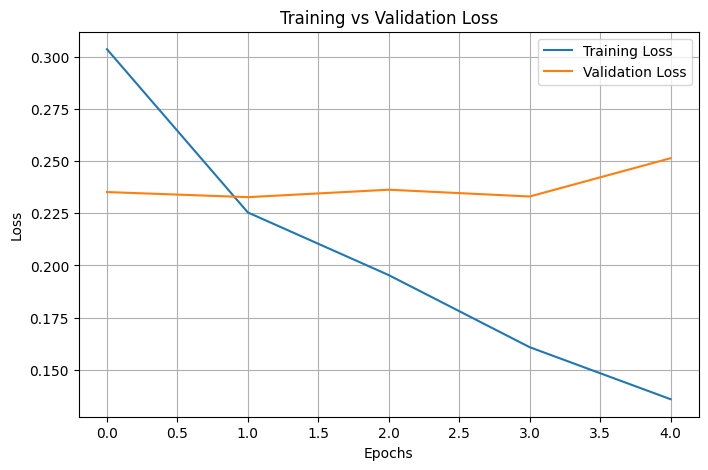

In [36]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8,5))
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.show()

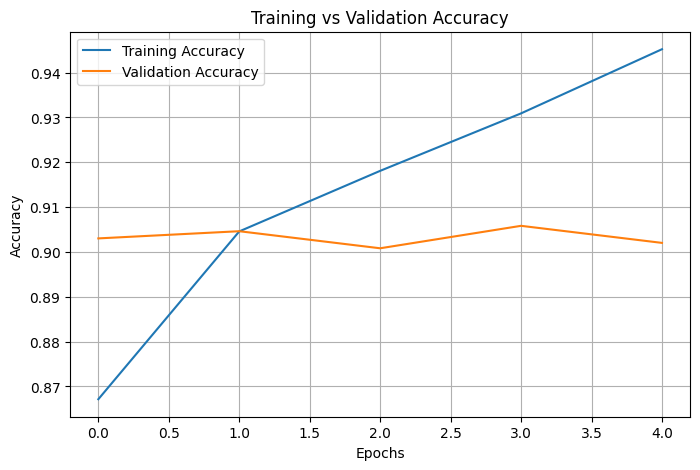

In [ ]:
# Accuracy values
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.figure(figsize=(8,5))
plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

plt.show()

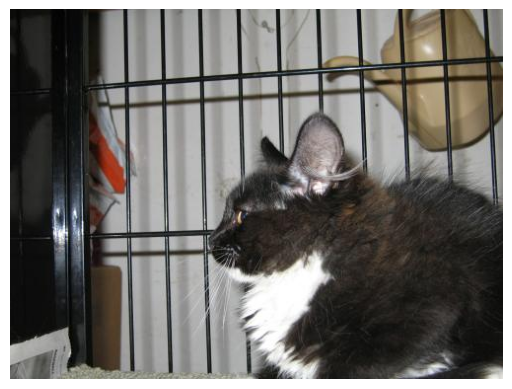

1/1 [==============================] - 0s 18ms/step


array([[0.12299485]], dtype=float32)

In [41]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('../data/test/Cat/231.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis('off')  
plt.show()

img = cv2.resize(img, (128, 128))
img = img / 255.0   # 🔥 IMPORTANT
img = np.expand_dims(img, axis=0)

model.predict(img)


In [42]:
model.save("my_model.keras")